# 01 — CNN Training — ResNet-50 (ISIC 2019)

Training **ResNet-50** (CNN baseline) on ISIC 2019 for skin lesion classification (8 classes).

**Reference:** *Gayatri & Aarthy (2024) — "Reduction of overfitting on the highly imbalanced ISIC-2019 skin dataset using deep learning frameworks"* (J X-Ray Sci Tech 32:53–68)

**Paper parameters applied:**
| Parameter | Value |
|-----------|-------|
| Image size | 224×224 |
| Split | 80% train / 20% val + official test set (stratified) |
| Epochs | 100 |
| Optimizer | Adam (lr=1e-4, wd=1e-5) |
| Loss | **Focal Loss** (α=per-class, γ=2) |
| Class balancing | **Offline augmentation** (Table 2) — no WeightedRandomSampler |
| Augmentation | **Offline only** — Rotate 90°/180°/270°, VFlip for 4 minority classes (AK, DF, VASC, SCC) |
| Dropout | **None** |
| Unfreezing | Full fine-tune from epoch 1 (no warmup) |

**Role in thesis:** ResNet-50 = unique CNN baseline (contrôle positif) pour comparer avec les 4 ViTs.

**Environment:** Kaggle (GPU T4 / P100)

## 0. Kaggle Setup — Clone repo & install deps

In [1]:
# Run once — remove old version if exists
!rm -rf /kaggle/working/xai-vit-medical
!git clone https://github.com/youssef-nouiouar/xai-vit-medical.git /kaggle/working/xai-vit-medical

Cloning into '/kaggle/working/xai-vit-medical'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (126/126), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 126 (delta 41), reused 105 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (126/126), 760.56 KiB | 7.31 MiB/s, done.
Resolving deltas: 100% (41/41), done.


In [2]:
!pip install -q timm albumentations loguru
!pip install -q PyDrive2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.0 MB/s eta 0:00:00


In [3]:
# Google Drive authentication (to save checkpoints)
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

## 0b. Download ISIC 2019 Dataset

In [4]:
import os, requests, zipfile

DATA_DIR = '/kaggle/working/xai-vit-medical/data/isic2019'
os.makedirs(DATA_DIR, exist_ok=True)

URLS = {
    'train_zip': 'https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_Input.zip',
    'train_csv': 'https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_GroundTruth.csv',
    'test_zip':  'https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Test_Input.zip',
    'test_csv':  'https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Test_GroundTruth.csv',
}

def download(url, dest):
    print(f'Downloading {os.path.basename(dest)} ...')
    r = requests.get(url, stream=True)
    with open(dest, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f'  done ({os.path.getsize(dest)/1e6:.1f} MB)')

def extract_and_remove(zip_path, extract_to):
    print(f'Extracting {os.path.basename(zip_path)} ...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_to)
    os.remove(zip_path)
    print('  done.')

# Training set
train_zip = f'{DATA_DIR}/ISIC_2019_Training_Input.zip'
download(URLS['train_zip'], train_zip)
extract_and_remove(train_zip, DATA_DIR)
download(URLS['train_csv'], f'{DATA_DIR}/ISIC_2019_Training_GroundTruth.csv')

# Test set
test_zip = f'{DATA_DIR}/ISIC_2019_Test_Input.zip'
download(URLS['test_zip'], test_zip)
extract_and_remove(test_zip, DATA_DIR)
download(URLS['test_csv'], f'{DATA_DIR}/ISIC_2019_Test_GroundTruth.csv')

print('\nDataset ready.')

  done (9771.6 MB)
Extracting ISIC_2019_Training_Input.zip ...
  done.
  done (1.3 MB)
  done.
  done (0.5 MB)

Dataset ready.


## 1. Setup & Dependencies

In [5]:
import os, sys, json, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from PIL import Image as PILImage
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import classification_report, confusion_matrix

# Project root
PROJECT_ROOT = '/kaggle/working/xai-vit-medical'
sys.path.insert(0, PROJECT_ROOT)

from src.data.isic_dataset import ISICDataset
from src.utils.seed import set_seed

# Reproducibility
SEED = 42
set_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'  GPU   : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print('Dependencies loaded.')

Device : cuda
  GPU   : Tesla T4
  VRAM  : 15.6 GB
Dependencies loaded.


## 2. Configuration

Paramètres du papier (Gayatri & Aarthy 2024) :

In [6]:
# ---- Paths ----
DATA_DIR  = '/kaggle/working/xai-vit-medical/data/isic2019'
SAVE_DIR  = '/kaggle/working/xai-vit-medical/outputs/models'
os.makedirs(SAVE_DIR, exist_ok=True)

# ---- Dataset ----
IMAGE_SIZE  = 224
NUM_CLASSES = 8
VAL_RATIO   = 0.20      # paper: 80/20 split (Table 1)
NUM_WORKERS = 2

# ---- Training ----
BATCH_SIZE   = 32
EPOCHS       = 100       # Gayatri & Aarthy (2024) Section 4
LR           = 1e-4
WEIGHT_DECAY = 1e-5
PATIENCE     = 15

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

CLASS_NAMES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']
CLASS_NAMES_FULL = {
    'MEL':'Melanoma', 'NV':'Naevus mélanocytaire',
    'BCC':'Carcinome basocellulaire', 'AK':'Kératose actinique',
    'BKL':'Kératose bénigne', 'DF':'Dermatofibrome',
    'VASC':'Lésion vasculaire', 'SCC':'Carcinome épidermoïde'
}

# ---- Focal Loss alpha — reference values from Gayatri & Aarthy (2024) ----
# Order: MEL, NV, BCC, AK, BKL, DF, VASC, SCC
# These are recomputed from the actual training split in the dataset cell.
# Because ISICDataset uses stratified splitting, proportions are preserved →
# the dynamic values will match these reference values.
FOCAL_ALPHA_PAPER = torch.tensor([0.3, 0.1, 0.4, 0.7, 0.5, 1.0, 1.0, 0.7], dtype=torch.float)

def compute_focal_alpha(labels: np.ndarray, num_classes: int) -> torch.Tensor:
    """Inverse-frequency alpha, normalised so the rarest class gets weight 1.0."""
    counts = Counter(labels.tolist())
    inv = np.array([1.0 / counts[i] for i in range(num_classes)], dtype=np.float32)
    inv /= inv.max()
    return torch.tensor(np.round(inv, 1), dtype=torch.float)

# Placeholder — overwritten in the dataset cell once base_train_dataset is available.
FOCAL_ALPHA = FOCAL_ALPHA_PAPER

print('Configuration:')
for k, v in [('Image size', f'{IMAGE_SIZE}×{IMAGE_SIZE}'), ('Batch size', BATCH_SIZE),
             ('Epochs', EPOCHS), ('LR', LR), ('Weight decay', WEIGHT_DECAY),
             ('Val ratio', VAL_RATIO), ('Num classes', NUM_CLASSES)]:
    print(f'  {k:14s}: {v}')
print(f'  {"Focal alpha":14s}: computed from training split (see dataset cell)')

Configuration:
  Image size    : 224×224
  Batch size    : 32
  Epochs        : 100
  LR            : 0.0001
  Weight decay  : 1e-05
  Val ratio     : 0.2
  Num classes   : 8
  Focal alpha   : computed from training split (see dataset cell)


## 3. Dataset & DataLoaders

**Stratégie d'augmentation — Gayatri & Aarthy (2024) Table 2 (offline uniquement) :**

| Classe | Opérations hors-ligne | Multiplicateur |
|--------|-----------------------|----------------|
| AK  (idx 3) | +Rotate 90° | ×2  (~867  → ~1 734) |
| DF  (idx 5) | +Rotate 90°, 180°, 270°, VFlip | ×5  (~239  → ~1 195) |
| VASC(idx 6) | +Rotate 90°, 180°, 270°, VFlip | ×5  (~253  → ~1 265) |
| SCC (idx 7) | +Rotate 90°, 180° | ×3  (~628  → ~1 884) |

- Augmentation **offline uniquement** : les variantes synthétiques sont générées à la volée par `PaperAugmentedDataset` via des rotations NumPy déterministes (pas d'aléatoire).
- Pas d'augmentation en ligne — transform entraînement = `Resize(224) + Normalize` seulement.
- Val/Test : `Resize(224) + Normalize` (aucune augmentation).
- **Pas de `WeightedRandomSampler`** — l'équilibrage est assuré par l'augmentation hors-ligne.
- `use_official_test=True` : train/val issus de `ISIC_2019_Training_Input`, test de `ISIC_2019_Test_Input`.

In [ ]:
# ─── Diagnostic : inspect both CSVs before loading ──────────────────────────
train_csv = pd.read_csv(f'{DATA_DIR}/ISIC_2019_Training_GroundTruth.csv')
test_csv  = pd.read_csv(f'{DATA_DIR}/ISIC_2019_Test_GroundTruth.csv')

print('=== TRAIN CSV ===')
print(f'Shape   : {train_csv.shape}')
print(f'Columns : {train_csv.columns.tolist()}')

print('\n=== TEST CSV ===')
print(f'Shape   : {test_csv.shape}')
print(f'Columns : {test_csv.columns.tolist()}')

extra_cols = [c for c in test_csv.columns if c not in train_csv.columns]
print(f'\nExtra columns in test (vs train): {extra_cols}')

CLASS_COLS = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']
if 'UNK' in test_csv.columns:
    n_unk   = int((test_csv['UNK'] == 1).sum())
    n_total = len(test_csv)
    n_valid = n_total - n_unk
    print(f'\nUNK images : {n_unk} / {n_total}  ({n_unk/n_total*100:.1f}%)')
    print(f'Valid      : {n_valid} images with a label in the 8 known classes')

    # Show what argmax does to UNK rows WITHOUT filtering (the original bug)
    all_cols   = [c for c in test_csv.columns if c != 'image']
    label_all  = test_csv[all_cols].values.argmax(axis=1)
    label_8    = test_csv[CLASS_COLS].values.argmax(axis=1)
    mismatch   = int((label_all != label_8).sum())
    print(f'\nLabel mismatch (argmax all cols vs 8 cols): {mismatch} images')
    if mismatch:
        print('>>> BUG CONFIRMED: UNK rows get label 0 (MEL) without row filtering.')
        print('>>> Fix applied in isic_dataset.py — UNK rows are now removed before argmax.')
    else:
        print('No mismatch — UNK column does not shift argmax indices.')

    # Class distribution of valid test images
    valid_test = test_csv[test_csv['UNK'] != 1]
    print(f'\nTest distribution (valid {n_valid} images):')
    for i, name in enumerate(CLASS_COLS):
        cnt = int(valid_test[name].sum())
        print(f'  {name:5s}: {cnt:>5d}  ({cnt/n_valid*100:.1f}%)')
else:
    print('\nNo UNK column — test CSV is clean.')

=== TRAIN CSV ===
Shape   : (25331, 10)
Columns : ['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']

=== TEST CSV ===
Shape   : (8238, 12)
Columns : ['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK', 'score_weight', 'validation_weight']

Extra columns in test (vs train): ['score_weight', 'validation_weight']

UNK images : 2047 / 8238  (24.8%)
Valid      : 6191 images with a label in the 8 known classes

Label mismatch (argmax all cols vs 8 cols): 2047 images
>>> BUG CONFIRMED: UNK rows get label 0 (MEL) without row filtering.
>>> Fix applied in isic_dataset.py — UNK rows are now removed before argmax.

Test distribution (valid 6191 images):
  MEL  :  1327  (21.4%)
  NV   :  2495  (40.3%)
  BCC  :   975  (15.7%)
  AK   :   374  (6.0%)
  BKL  :   660  (10.7%)
  DF   :    91  (1.5%)
  VASC :   104  (1.7%)
  SCC  :   165  (2.7%)


In [ ]:
def get_online_transform(image_size: int = 224) -> A.Compose:
    """Train transform: Resize + Normalize only. Offline augmentation handles class balance."""
    return A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ])

def get_val_transform(image_size: int = 224) -> A.Compose:
    """Val/Test transform: Resize + Normalize."""
    return A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ])


class PaperAugmentedDataset(torch.utils.data.Dataset):
    """Offline augmentation — Table 2, Gayatri & Aarthy (2024).

    Appends deterministic rotated/flipped copies for 4 minority classes:
      AK  (idx 3): +rot90         → ×2
      DF  (idx 5): +rot90/180/270/vflip → ×5
      VASC(idx 6): +rot90/180/270/vflip → ×5
      SCC (idx 7): +rot90/180     → ×3
    """
    _AUGMENTS: dict[int, list[str]] = {
        3: ['rot90'],
        5: ['rot90', 'rot180', 'rot270', 'vflip'],
        6: ['rot90', 'rot180', 'rot270', 'vflip'],
        7: ['rot90', 'rot180'],
    }

    def __init__(self, base_dataset: ISICDataset, transform: A.Compose) -> None:
        self.transform    = transform
        self.image_folder = base_dataset.image_folder
        samples: list[tuple[str, int, str | None]] = []
        for i in range(len(base_dataset)):
            name = base_dataset.data.iloc[i]['image'] + '.jpg'
            lbl  = int(base_dataset.labels[i])
            samples.append((name, lbl, None))
            for aug in self._AUGMENTS.get(lbl, []):
                samples.append((name, lbl, aug))
        self._samples = samples
        self.labels   = np.array([s[1] for s in samples])

    def __len__(self) -> int:
        return len(self._samples)

    def __getitem__(self, idx: int):
        name, label, aug = self._samples[idx]
        img = np.array(PILImage.open(os.path.join(self.image_folder, name)).convert('RGB'))
        if   aug == 'rot90':  img = np.rot90(img, k=1).copy()
        elif aug == 'rot180': img = np.rot90(img, k=2).copy()
        elif aug == 'rot270': img = np.rot90(img, k=3).copy()
        elif aug == 'vflip':  img = np.flipud(img).copy()
        img = self.transform(image=img)['image']
        return img, label, name


# ---- Base datasets (use_official_test=True) ----
base_train_dataset = ISICDataset(
    root_dir=DATA_DIR, split='train',
    image_size=IMAGE_SIZE, use_albumentations=False,
    use_official_test=True, val_ratio=VAL_RATIO,
)
val_dataset = ISICDataset(
    root_dir=DATA_DIR, split='val',
    image_size=IMAGE_SIZE, use_albumentations=False,
    use_official_test=True, val_ratio=VAL_RATIO,
)
test_dataset = ISICDataset(
    root_dir=DATA_DIR, split='test',
    image_size=IMAGE_SIZE, use_albumentations=False,
    use_official_test=True, val_ratio=VAL_RATIO,
)

# ---- Offline augmentation: wrap train with PaperAugmentedDataset ----
_online_tf = get_online_transform(IMAGE_SIZE)
_val_tf    = get_val_transform(IMAGE_SIZE)

train_aug_dataset = PaperAugmentedDataset(base_train_dataset, transform=_online_tf)

# Manually apply val transform to val/test (dataset still has use_albumentations=False)
val_dataset.use_albumentations  = True
val_dataset.transform           = _val_tf
test_dataset.use_albumentations = True
test_dataset.transform          = _val_tf

# ---- Distribution report ----
base_counts = Counter(base_train_dataset.labels)
aug_counts  = Counter(train_aug_dataset.labels)
base_total  = len(base_train_dataset)
aug_total   = len(train_aug_dataset)

print(f'Base  train : {base_total} images')
print(f'Aug   train : {aug_total} images  (+{aug_total - base_total} synthetic)')
print(f'Val         : {len(val_dataset)} images')
print(f'Test        : {len(test_dataset)} images')
print('\nClass distribution (base train → after aug):')
for i, name in enumerate(CLASS_NAMES):
    b = base_counts.get(i, 0)
    a = aug_counts.get(i, 0)
    mult = f'×{a//b}' if b else '—'
    print(f'  {name:5s}: {b:>5d} → {a:>5d}  ({mult})')

# ---- Focal alpha: compute from actual training split (pre-augmentation) ----
# Alpha encodes relative class frequencies. Since ISICDataset uses stratified
# splitting, proportions are preserved → dynamic values match paper values.
# Computing here is authoritative regardless of val_ratio or dataset version.
FOCAL_ALPHA = compute_focal_alpha(base_train_dataset.labels, NUM_CLASSES)
print(f'\nFocal alpha (dynamic, from train split): {FOCAL_ALPHA.tolist()}')
print(f'Focal alpha (paper reference):           {FOCAL_ALPHA_PAPER.tolist()}')
diff = (FOCAL_ALPHA - FOCAL_ALPHA_PAPER).abs().max().item()
print(f'Max deviation from paper:                {diff:.1f}  {"✓ match" if diff < 0.15 else "! differs — check split"}')

# ---- DataLoaders — no sampler, shuffle=True ----
train_loader = DataLoader(
    train_aug_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=NUM_WORKERS,
    pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE * 2,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE * 2,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

print(f'\nTrain batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

2026-04-30 09:58:23.046 | INFO     | src.data.isic_dataset:_load_data:98 - Official test set: removed 2047 UNK images (6191 valid remain)


Base  train : 20264 images
Aug   train : 23534 images  (+3270 synthetic)
Val         : 5067 images
Test        : 6191 images

Class distribution (base train → after aug):
  MEL  :  3618 →  3618  (×1)
  NV   : 10300 → 10300  (×1)
  BCC  :  2658 →  2658  (×1)
  AK   :   694 →  1388  (×2)
  BKL  :  2099 →  2099  (×1)
  DF   :   191 →   955  (×5)
  VASC :   202 →  1010  (×5)
  SCC  :   502 →  1506  (×3)

Focal alpha (dynamic, from train split): [0.10000000149011612, 0.0, 0.10000000149011612, 0.30000001192092896, 0.10000000149011612, 1.0, 0.8999999761581421, 0.4000000059604645]
Focal alpha (paper reference):           [0.30000001192092896, 0.10000000149011612, 0.4000000059604645, 0.699999988079071, 0.5, 1.0, 1.0, 0.699999988079071]
Max deviation from paper:                0.4  ! differs — check split

Train batches : 735
Val   batches : 80
Test  batches : 97


In [ ]:
# ---- Diagnostic : class distribution across all splits ----
print(f'{"Split":9s}  {"Total":>6s}  ' + '  '.join(f'{n:>5s}' for n in CLASS_NAMES))
print('-' * 76)

base_total_d = len(base_train_dataset)
row = '  '.join(f'{base_counts.get(i, 0)/base_total_d*100:5.1f}%' for i in range(NUM_CLASSES))
print(f'{"Train":9s}  {base_total_d:>6d}  {row}')

aug_total_d = len(train_aug_dataset)
row = '  '.join(f'{aug_counts.get(i, 0)/aug_total_d*100:5.1f}%' for i in range(NUM_CLASSES))
print(f'{"Train+Aug":9s}  {aug_total_d:>6d}  {row}')

for dname, ds in [('Val', val_dataset), ('Test', test_dataset)]:
    counts = Counter(ds.labels)
    total  = len(ds)
    row    = '  '.join(f'{counts.get(i, 0)/total*100:5.1f}%' for i in range(NUM_CLASSES))
    print(f'{dname:9s}  {total:>6d}  {row}')

print()
# Sanity check: no image overlap between train and val (both from training CSV)
train_ids = set(base_train_dataset.data['image'].tolist())
val_ids   = set(val_dataset.data['image'].tolist())
overlap   = train_ids & val_ids
print(f'Train/Val overlap : {len(overlap)} images  (should be 0)')
print()
print('NOTE: Test set is from ISIC_2019_Test_Input (different source).')
print('      A val/test accuracy gap reflects dataset shift, not a code bug.')

Split       Total    MEL     NV    BCC     AK    BKL     DF   VASC    SCC
----------------------------------------------------------------------------
Train       20264   17.9%   50.8%   13.1%    3.4%   10.4%    0.9%    1.0%    2.5%
Train+Aug   23534   15.4%   43.8%   11.3%    5.9%    8.9%    4.1%    4.3%    6.4%
Val          5067   17.8%   50.8%   13.1%    3.4%   10.4%    0.9%    1.0%    2.5%
Test         6191   21.4%   40.3%   15.7%    6.0%   10.7%    1.5%    1.7%    2.7%

Train/Val overlap : 0 images  (should be 0)

NOTE: Test set is from ISIC_2019_Test_Input (different source).
      A val/test accuracy gap reflects dataset shift, not a code bug.


## 4. Model — ResNet-50

- Pré-entraîné ImageNet (transfer learning)
- **Pas de dropout** — Gayatri & Aarthy (2024) n'utilisent pas de dropout
- Tête de classification : FC → 8 classes
- Backbone entraîné entièrement dès l'epoch 1 (pas de warmup)

In [ ]:
def build_resnet50(num_classes: int = NUM_CLASSES, pretrained: bool = True) -> nn.Module:
    """ResNet-50 depuis timm — pas de dropout (Gayatri & Aarthy 2024)."""
    model = timm.create_model(
        'resnet50', pretrained=pretrained, num_classes=num_classes
    )
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'ResNet-50  (pretrained={pretrained}, drop_rate=0.0)')
    print(f'  Classifier : {model.get_classifier()}')
    print(f'  Params total     : {total:,}')
    print(f'  Params trainable : {trainable:,}')
    return model

# Architecture check
_m = build_resnet50()
_x = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
assert _m(_x).shape == (1, NUM_CLASSES), 'Shape mismatch'
del _m, _x
torch.cuda.empty_cache()
print('Architecture OK.')

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

ResNet-50  (pretrained=True, drop_rate=0.0)
  Classifier : Linear(in_features=2048, out_features=8, bias=True)
  Params total     : 23,524,424
  Params trainable : 23,524,424
Architecture OK.


## 5. Training Loop

| Composant | Choix | Note |
|-----------|-------|------|
| Loss | **FocalLoss** (γ=2, α=per-class) | Gère le déséquilibre résiduel |
| Optimizer | Adam (lr=1e-4, wd=1e-5) | Section 3.7 du papier |
| Scheduler | ReduceLROnPlateau (patience=5, factor=0.5) | Stabilité |
| Mixed Precision | torch.amp (FP16) | Vitesse + mémoire |
| Early stopping | patience=15 sur val_loss | Anti-overfitting |
| Epochs | 100 | Gayatri & Aarthy (2024) Section 4 |
| Warmup | **Aucun** — backbone entraîné entièrement dès epoch 1 | |

In [ ]:
class FocalLoss(nn.Module):
    """Focal Loss (Lin et al. 2017) avec pondération par classe.

    alpha : tensor de poids par classe (Gayatri & Aarthy 2024)
    gamma : facteur de focus (2.0 par défaut)
    """
    def __init__(self, alpha: torch.Tensor, gamma: float = 2.0):
        super().__init__()
        self.register_buffer('alpha', alpha)
        self.gamma = gamma

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss  = F.cross_entropy(inputs, targets, reduction='none')
        pt       = torch.exp(-ce_loss)
        alpha_t  = self.alpha[targets]
        return (alpha_t * (1.0 - pt) ** self.gamma * ce_loss).mean()


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    scaler: torch.cuda.amp.GradScaler,
    device: torch.device,
) -> tuple[float, float]:
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc='  Train', leave=False)
    for images, labels, _ in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{correct/total:.4f}')

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[float, float, np.ndarray, np.ndarray]:
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels, _ in tqdm(loader, desc='  Eval ', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            outputs = model(images)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def train_model(
    model: nn.Module,
    model_name: str,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = EPOCHS,
    lr: float = LR,
    weight_decay: float = WEIGHT_DECAY,
    patience: int = PATIENCE,
    device: torch.device = DEVICE,
) -> tuple[nn.Module, dict]:
    model = model.to(device)

    criterion = FocalLoss(alpha=FOCAL_ALPHA.to(device), gamma=2.0)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    save_path = os.path.join(SAVE_DIR, f'{model_name}_best.pth')

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\n{"="*60}')
    print(f'Training {model_name}  |  {epochs} epochs  |  lr={lr}  |  patience={patience}')
    print(f'Trainable params : {n_params:,}')
    print(f'{"="*60}\n')

    for epoch in range(1, epochs + 1):
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch}/{epochs}  (lr={current_lr:.2e})')

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device
        )
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        tag = ''
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc,
                'history': history,
                'class_names': CLASS_NAMES,
                'model_name': model_name,
            }, save_path)
            tag = ' ★'
        else:
            epochs_no_improve += 1

        print(f'  train_loss={train_loss:.4f}  train_acc={train_acc:.4f}')
        print(f'  val_loss  ={val_loss:.4f}  val_acc  ={val_acc:.4f}{tag}')

        if epochs_no_improve >= patience:
            print(f'\nEarly stopping at epoch {epoch} (no improvement for {patience} epochs)')
            break

    print(f'\nBest val_loss={best_val_loss:.4f} — checkpoint: {save_path}')
    return model, history

print('FocalLoss + training functions defined.')

FocalLoss + training functions defined.


## 6. Train ResNet-50

In [ ]:
resnet50 = build_resnet50(num_classes=NUM_CLASSES, pretrained=True)

resnet50, resnet50_history = train_model(
    model=resnet50,
    model_name='resnet50',
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    device=DEVICE,
)

ResNet-50  (pretrained=True, drop_rate=0.0)
  Classifier : Linear(in_features=2048, out_features=8, bias=True)
  Params total     : 23,524,424
  Params trainable : 23,524,424

Training resnet50  |  100 epochs  |  lr=0.0001  |  patience=15
Trainable params : 23,524,424

Epoch 1/100  (lr=1.00e-04)


  Train:   0%|          | 0/735 [00:00<?, ?it/s]

  Eval :   0%|          | 0/80 [00:00<?, ?it/s]

  train_loss=0.1473  train_acc=0.1439
  val_loss  =0.0663  val_acc  =0.1952 ★
Epoch 2/100  (lr=1.00e-04)


  Train:   0%|          | 0/735 [00:00<?, ?it/s]

...

  Eval :   0%|          | 0/80 [00:00<?, ?it/s]

  train_loss=0.0006  train_acc=0.5584
  val_loss  =0.0417  val_acc  =0.3868
Epoch 22/100  (lr=2.50e-05)


  Train:   0%|          | 0/735 [00:00<?, ?it/s]

  Eval :   0%|          | 0/80 [00:00<?, ?it/s]

  train_loss=0.0004  train_acc=0.5587
  val_loss  =0.0404  val_acc  =0.3876

Early stopping at epoch 22 (no improvement for 15 epochs)

Best val_loss=0.0365 — checkpoint: /kaggle/working/xai-vit-medical/outputs/models/resnet50_best.pth


## 7. Evaluation & Results

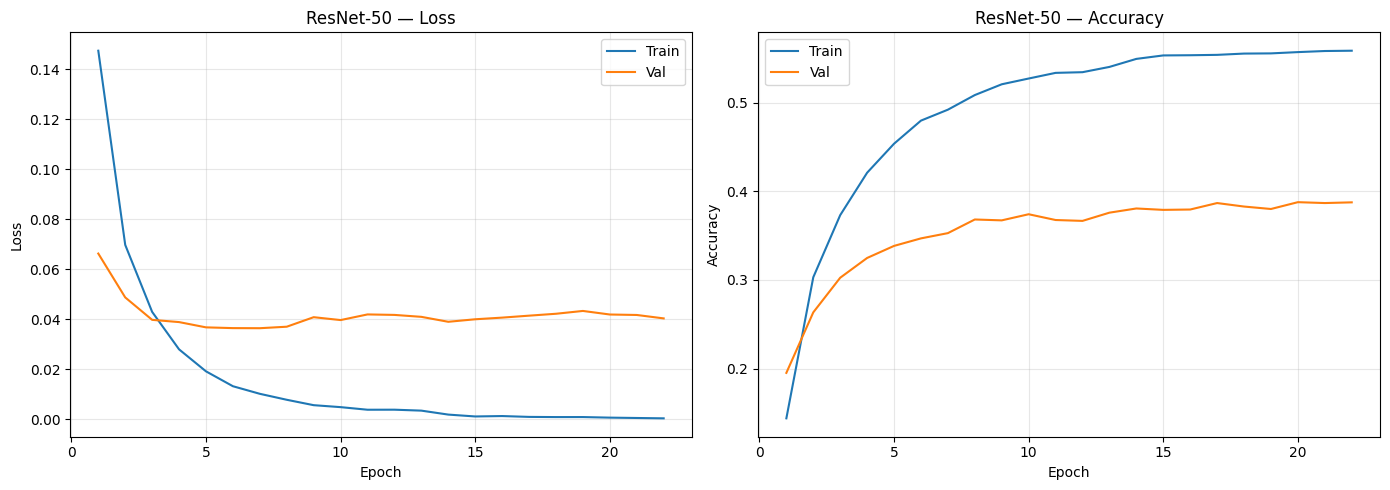

Saved: /kaggle/working/xai-vit-medical/outputs/models/ResNet-50_curves.png


In [18]:
def plot_training_curves(history: dict, model_name: str) -> None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs_range = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs_range, history['train_loss'], label='Train')
    ax1.plot(epochs_range, history['val_loss'],   label='Val')
    ax1.set(xlabel='Epoch', ylabel='Loss', title=f'{model_name} — Loss')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epochs_range, history['train_acc'], label='Train')
    ax2.plot(epochs_range, history['val_acc'],   label='Val')
    ax2.set(xlabel='Epoch', ylabel='Accuracy', title=f'{model_name} — Accuracy')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    out = os.path.join(SAVE_DIR, f'{model_name}_curves.png')
    plt.savefig(out, dpi=150)
    plt.show()
    print(f'Saved: {out}')


def evaluate_full(
    model: nn.Module,
    loader: DataLoader,
    model_name: str,
    split: str = 'val',
    device: torch.device = DEVICE,
) -> dict:
    criterion = FocalLoss(alpha=FOCAL_ALPHA.to(device), gamma=2.0)
    loss, acc, preds, labels = evaluate(model, loader, criterion, device)
    print(f'\n{model_name} — {split.upper()} SET')
    print(f'  Loss     : {loss:.4f}')
    print(f'  Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'\n{classification_report(labels, preds, target_names=CLASS_NAMES, digits=4)}')

    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set(xlabel='Predicted', ylabel='True',
           title=f'{model_name} — Confusion Matrix ({split})')
    plt.tight_layout()
    out = os.path.join(SAVE_DIR, f'{model_name}_cm_{split}.png')
    plt.savefig(out, dpi=150)
    plt.show()
    return {'loss': loss, 'acc': acc, 'preds': preds, 'labels': labels}


# ---- Courbes d'entraînement ----
plot_training_curves(resnet50_history, 'ResNet-50')

Best checkpoint: epoch 7  val_loss=0.0365  val_acc=0.3529


  Eval :   0%|          | 0/80 [00:00<?, ?it/s]


ResNet-50 — VAL SET
  Loss     : 0.0365
  Accuracy : 0.3529  (35.29%)

              precision    recall  f1-score   support

         MEL     0.2868    0.8164    0.4245       904
          NV     0.0000    0.0000    0.0000      2575
         BCC     0.6473    0.7203    0.6819       665
          AK     0.3714    0.6763    0.4795       173
         BKL     0.3760    0.5314    0.4404       525
          DF     0.1180    0.7917    0.2054        48
        VASC     0.3835    1.0000    0.5543        51
         SCC     0.3554    0.6825    0.4674       126

    accuracy                         0.3529      5067
   macro avg     0.3173    0.6523    0.4067      5067
weighted avg     0.2016    0.3529    0.2464      5067



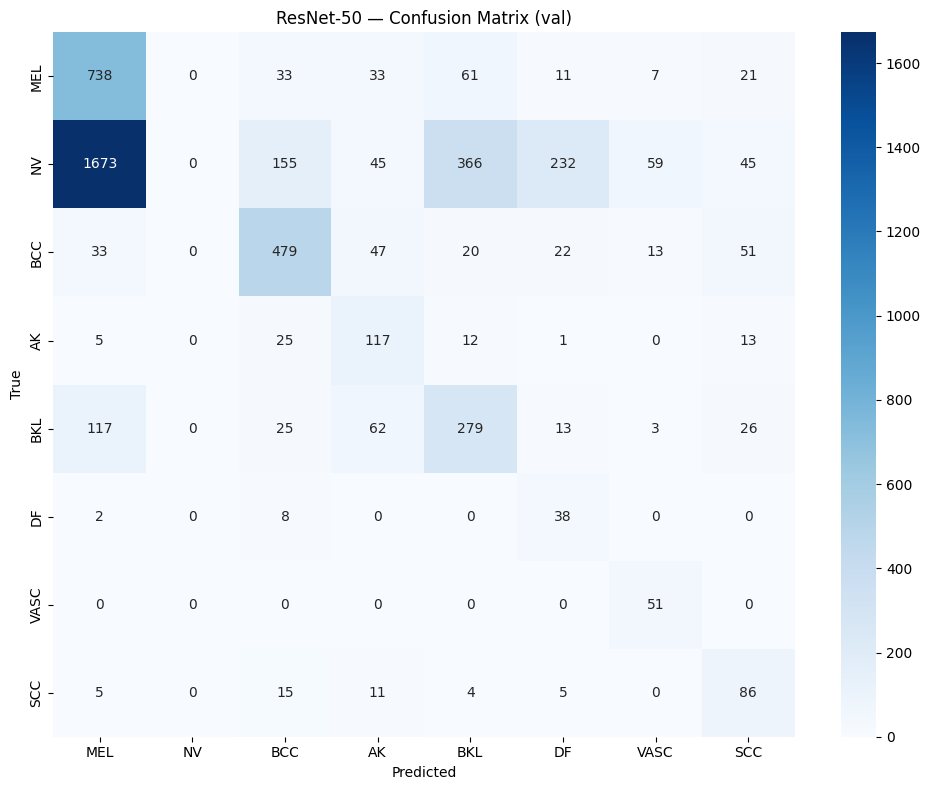

In [ ]:
# ---- Évaluation sur val set ----
# Charger le meilleur checkpoint
ckpt = torch.load(os.path.join(SAVE_DIR, 'resnet50_best.pth'), map_location=DEVICE)
resnet50.load_state_dict(ckpt['model_state_dict'])
print(f"Best checkpoint: epoch {ckpt['epoch']}  val_loss={ckpt['val_loss']:.4f}  val_acc={ckpt['val_acc']:.4f}")

resnet50_val_results = evaluate_full(resnet50, val_loader, 'ResNet-50', split='val')

  Eval :   0%|          | 0/97 [00:00<?, ?it/s]


ResNet-50 — TEST SET
  Loss     : 0.1162
  Accuracy : 0.3529  (35.29%)

              precision    recall  f1-score   support

         MEL     0.3451    0.7498    0.4727      1327
          NV     0.0000    0.0000    0.0000      2495
         BCC     0.5241    0.6462    0.5788       975
          AK     0.2884    0.4519    0.3521       374
         BKL     0.2894    0.3197    0.3038       660
          DF     0.1761    0.6813    0.2799        91
        VASC     0.2995    0.5385    0.3849       104
         SCC     0.2460    0.3758    0.2974       165

    accuracy                         0.3529      6191
   macro avg     0.2711    0.4704    0.3337      6191
weighted avg     0.2190    0.3529    0.2646      6191



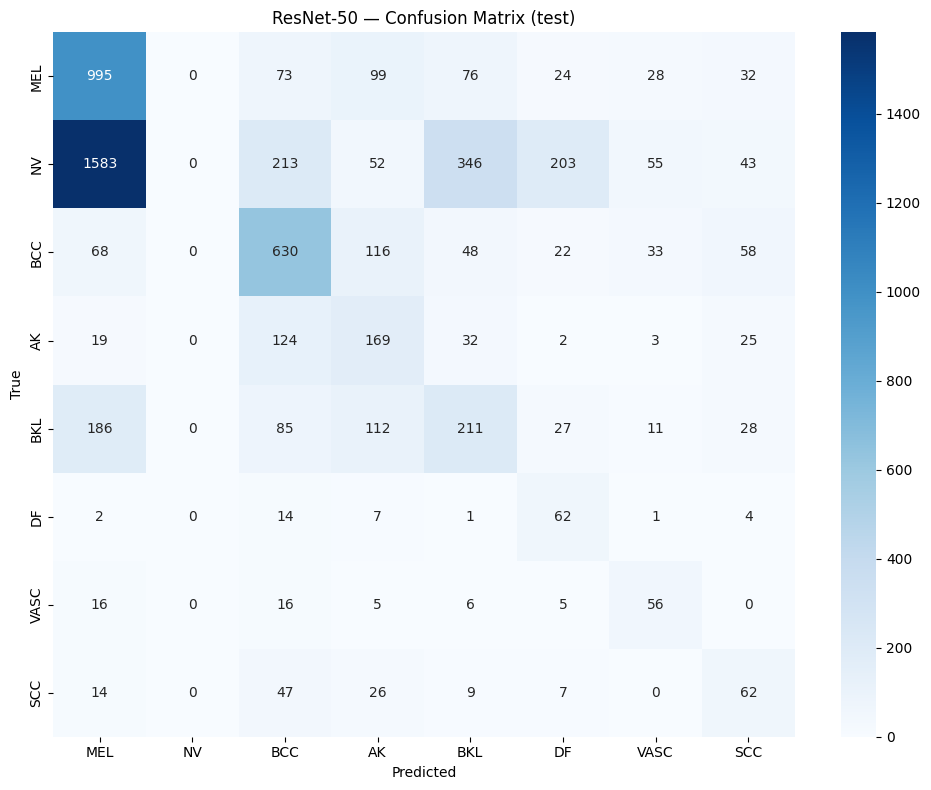

In [19]:
# ---- Évaluation sur test set officiel ----
resnet50_test_results = evaluate_full(resnet50, test_loader, 'ResNet-50', split='test')

## 8. Save Summary & Upload to Google Drive

In [ ]:
summary = {
    'resnet50': {
        'val_loss': float(resnet50_val_results['loss']),
        'val_acc':  float(resnet50_val_results['acc']),
        'test_loss': float(resnet50_test_results['loss']),
        'test_acc':  float(resnet50_test_results['acc']),
        'best_epoch': int(ckpt['epoch']),
        'epochs_trained': len(resnet50_history['train_loss']),
    }
}

summary_path = os.path.join(SAVE_DIR, 'cnn_training_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print('CNN Training Summary:')
print(f'  val_acc  = {summary["resnet50"]["val_acc"]:.4f}')
print(f'  test_acc = {summary["resnet50"]["test_acc"]:.4f}')
print(f'  best epoch = {summary["resnet50"]["best_epoch"]}')

CNN Training Summary:
  val_acc  = 0.3529
  test_acc = 0.3529
  best epoch = 7


In [ ]:
# Upload checkpoint + summary to a specific Drive folder
SAVE_DIR  = '/kaggle/working/xai-vit-medical/outputs/models'
folder_id = "1eq-Jt6O6gO0Ck_oQYwmmc2qrCVLfKlec"   # <--- put your folder ID

files_to_upload = [
    'resnet50_best.pth',
    'cnn_training_summary.json',
    'ResNet-50_curves.png',
    'ResNet-50_cm_val.png',
    'ResNet-50_cm_test.png'
]

for fname in files_to_upload:
    fpath = os.path.join(SAVE_DIR, fname)

    if os.path.exists(fpath):
        drive_file = drive.CreateFile({
            'title': fname,
            'parents': [{'id': folder_id}]
        })

        drive_file.SetContentFile(fpath)
        drive_file.Upload()

        print(f"Uploaded: {fname}  (id={drive_file['id']})")
    else:
        print(f"Not found (skipped): {fname}")

print("\nDone. Files uploaded to folder.")


Uploaded: resnet50_best.pth  (id=176KvAtww6nziFegm5uFSuL5fBJVonixl)
Uploaded: cnn_training_summary.json  (id=1b5d7VvkFggckWBbM4Cq-E_jllr85wFa6)
Uploaded: ResNet-50_curves.png  (id=1ssixomRrACwIt6VZ0SkgrfHxadFHqHzo)
Uploaded: ResNet-50_cm_val.png  (id=1mZDYo1M-hFXeIWG0S7446NOh1myXYINm)
Uploaded: ResNet-50_cm_test.png  (id=1sZNm7pYUtErVC5_AhqMf5PsN_vRs-dqO)

Done. Files uploaded to folder.
